# Exploratory Data Analysis - Global AI & Data Jobs Salary Dataset

## Objective

The purpose of this exploratory data analysis is to understand the structure, quality, distributions and relationships within the Global AI & Data Jobs Salary Dataset.

The primary target variable is `salary_usd`. The analysis will investigate how salary varies with factors such as experience, job role, country, AI specialisation, education, industry and other employment-related characteristics.

In [6]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from hydra import compose, initialize

## 1. Set Project Root and Load Configuration

The project root directory is identified so that file paths can be resolved consistently from the main `mlops-assignment` folder.

`PROJECT_ROOT = Path.cwd().parents[1]`

Since the notebook is located inside `darren/notebooks/`, `Path.cwd()` returns the full path to the current notebook folder, for example:

`C:/Users/username/Documents/GitHub/mlops-assignment/darren/notebooks`

Using `.parents[1]` moves up two folder levels to the main `mlops-assignment` directory.

This allows the same code to work even if different team members store the project in different locations on their computers.

Next, Hydra is used to load the project configuration file.

`initialize(version_base=None, config_path="../conf")` tells Hydra that the configuration files are located inside the `darren/conf/` folder.

`compose(config_name="config")` loads `config.yaml` into `cfg`.

Finally,

`raw_data_path = PROJECT_ROOT / cfg.data.raw_path`

combines the project root with the dataset path defined inside `config.yaml`.

This avoids hard-coding a specific user's full file path and allows file paths to be managed centrally through the configuration file.

In [10]:
# Project root: .../mlops-assignment
PROJECT_ROOT = Path.cwd().parents[1]

with initialize(version_base=None, config_path="../conf"):
    cfg = compose(config_name="config")
    
raw_data_path = PROJECT_ROOT / cfg.data.raw_path

## 2. Load Dataset and Preview

The raw dataset is loaded using the file path obtained from the Hydra configuration. The first few records are displayed to verify that the dataset has been loaded correctly.

In [11]:
df = pd.read_csv(raw_data_path)

df.head()

,id,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,bonus_usd,education_required,industry,company_size,interview_rounds,year,work_mode,weekly_hours,company_rating,job_openings,hiring_difficulty_score,layoff_risk,ai_adoption_score,company_funding_billion,economic_index,ai_maturity_years,offer_acceptance_rate,tax_rate_percent,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
0,1,UAE,Machine Learning Engineer,Reinforcement Learning,Entry,0,66465,5395,Master,Automotive,Small,7,2020,Remote,44.7,3.67,10,52.765351,0.404,91,3.30,78.65,13,60.58,20.8,27,12,76,57,65,73,15,55,1.23,76
1,2,USA,AI Engineer,LLM,Entry,1,75507,11713,Bootcamp,Retail,Small,3,2021,Onsite,48.9,4.26,27,53.114580,0.387,71,4.39,62.14,13,75.80,28.4,27,54,29,69,60,51,15,58,0.87,67
2,3,Brazil,Research Scientist,Analytics,Entry,0,41660,5268,PhD,Healthcare,Large,3,2020,Remote,46.8,4.78,10,76.395263,0.415,69,5.04,87.47,8,62.95,12.2,13,12,49,70,59,68,37,13,2.13,61
3,4,India,Software Engineer AI,Computer Vision,Senior,6,43268,7975,Diploma,Tech,Large,2,2026,Onsite,52.2,4.34,23,59.340199,0.115,74,4.38,86.84,7,77.45,35.1,30,80,47,79,65,55,46,74,1.49,56
4,5,Germany,Machine Learning Engineer,Computer Vision,Entry,0,69119,4758,Master,Retail,Medium,2,2021,Hybrid,46.7,4.49,17,72.301128,0.311,68,6.67,79.84,7,89.86,36.1,24,82,47,64,52,69,17,21,0.87,72


## 3. Dataset Structure

The dataset contains **90,000 records and 35 variables**.

Among the 35 variables:
- **27 are numerical variables**, consisting of 18 integer (`int64`) and 9 decimal (`float64`) columns.
- **8 are categorical variables** stored as `object`, including `country`, `job_role`, `ai_specialization`, `experience_level`, `education_required`, `industry`, `company_size`, and `work_mode`.

The `id` column appears to serve as a unique record identifier rather than an explanatory feature and will be examined further before modelling.

All columns currently contain 90,000 non-null values.

The dataset contains job, salary, company, economic, and career-related variables. The following data dictionary describes the meaning of each feature based on the Kaggle dataset documentation (https://www.kaggle.com/datasets/mohankrishnathalla/global-ai-and-data-jobs-salary-dataset/data).

| Column | Description |
|---|---|
| `id` | Unique identifier for each job record. |
| `country` | Country where the job position is located. |
| `job_role` | Primary job title or role category, such as Data Scientist, ML Engineer, or Software Engineer. |
| `ai_specialization` | Specific AI or technical specialization area associated with the role. |
| `experience_level` | Seniority level of the position, such as Entry, Mid, Senior, Lead, or Executive. |
| `experience_years` | Required or typical years of professional experience for the role. |
| `salary_usd` | Estimated annual base salary in USD. |
| `bonus_usd` | Estimated annual bonus or additional compensation in USD. |
| `education_required` | Minimum education qualification required for the role. |
| `industry` | Industry sector of the hiring company. |
| `company_size` | Company size category based on employee count. |
| `interview_rounds` | Typical number of interview rounds in the hiring process. |
| `year` | Year when the job record is observed. |
| `work_mode` | Work arrangement type, such as Remote, Hybrid, or Onsite. |
| `weekly_hours` | Average expected working hours per week. |
| `company_rating` | Estimated company rating representing workplace reputation or employee feedback. |
| `job_openings` | Number of available openings for similar roles. |
| `hiring_difficulty_score` | Score indicating how difficult it is for companies to fill the role. |
| `layoff_risk` | Estimated probability or risk level of layoffs affecting the role. |
| `ai_adoption_score` | Score representing how strongly the company or industry adopts AI technologies. |
| `company_funding_billion` | Estimated company funding or valuation level in billions of USD. |
| `economic_index` | Economic condition indicator reflecting overall market strength. |
| `ai_maturity_years` | Estimated number of years the organisation has been actively using AI technologies. |
| `offer_acceptance_rate` | Percentage of job offers typically accepted by candidates. |
| `tax_rate_percent` | Estimated effective income tax rate percentage applicable to the salary. |
| `vacation_days` | Average number of annual paid vacation days. |
| `skill_demand_score` | Score representing market demand for the required skills. |
| `automation_risk` | Estimated likelihood that the role could be automated in the future. |
| `job_security_score` | Score representing long-term job stability and retention likelihood. |
| `career_growth_score` | Score indicating potential career advancement opportunities. |
| `work_life_balance_score` | Score estimating expected work-life balance quality. |
| `promotion_speed` | Estimated relative speed of promotions within the role or company. |
| `salary_percentile` | Salary percentile ranking compared to similar roles globally. |
| `cost_of_living_index` | Index representing relative cost of living in the job location. |
| `employee_satisfaction` | Estimated employee satisfaction level associated with similar roles. |

In [15]:
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")
print()
df.info()
print()
print(df.columns.tolist())

Number of rows: 90,000
Number of columns: 35

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       90000 non-null  int64  
 1   country                  90000 non-null  object 
 2   job_role                 90000 non-null  object 
 3   ai_specialization        90000 non-null  object 
 4   experience_level         90000 non-null  object 
 5   experience_years         90000 non-null  int64  
 6   salary_usd               90000 non-null  int64  
 7   bonus_usd                90000 non-null  int64  
 8   education_required       90000 non-null  object 
 9   industry                 90000 non-null  object 
 10  company_size             90000 non-null  object 
 11  interview_rounds         90000 non-null  int64  
 12  year                     90000 non-null  int64  
 13  work_mode                90000

## 4. Data Quality Assessment

Before performing further analysis, the dataset is checked for potential data quality issues that may affect the reliability of the analysis and subsequent machine learning model.

The following aspects are examined:

- Missing values
- Duplicate records
- Number of unique values in each column
- Consistency of categorical values
- Potential invalid or unrealistic numerical values

### 4.1 Missing Values

No missing values were found in any of the 35 variables. All 90,000 records contain complete values for every column.

Since there are no missing values, no missing-value imputation or removal is required.

In [16]:
missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values

,Missing Count,Missing Percentage (%)
id,0,0.0
country,0,0.0
job_role,0,0.0
ai_specialization,0,0.0
experience_level,0,0.0
experience_years,0,0.0
salary_usd,0,0.0
bonus_usd,0,0.0
education_required,0,0.0
industry,0,0.0


### 4.2 Duplicate Records

No fully duplicated records were found in the dataset.

This indicates that each of the 90,000 records is unique at the row level, so no duplicate rows need to be removed.

In [17]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate records: {duplicate_count}")

Number of duplicate records: 0


### 4.3 Unique Values

The number of unique values in each variable was examined to better understand the type and granularity of the features.

Several variables have low cardinality and can be treated as categorical features, such as `work_mode` (3 values), `experience_level` (4 values), `education_required` (5 values), `company_size` (5 values), `job_role` (8 values), `ai_specialization` (8 values), `industry` (10 values), and `country` (12 values).

The `id` column contains 90,000 unique values, which is equal to the total number of records. This indicates that it is a unique identifier for each record rather than a meaningful predictive feature. Which should be excluded out during modelling later.

Other variables such as `salary_usd`, `bonus_usd`, `hiring_difficulty_score`, and `economic_index` contain many unique values and behave more like continuous numerical variables.

In [18]:
unique_values = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": df.nunique().values
}).sort_values("Unique Values")

unique_values

,Column,Unique Values
13,work_mode,3
4,experience_level,4
8,education_required,5
10,company_size,5
11,interview_rounds,6
12,year,7
2,job_role,8
3,ai_specialization,8
9,industry,10
1,country,12


### 4.4 Categorical Value Consistency

The categorical variables were examined to identify inconsistent labels, spelling differences, or duplicated categories.

No obvious inconsistencies were found across the categorical variables. For example, values such as `Remote`, `Hybrid`, and `Onsite` are represented consistently, and categories such as `Entry`, `Mid`, `Senior`, and `Lead` do not contain alternative spellings or duplicate labels.

The category distributions are also relatively balanced across most variables. For example:

- `experience_level` contains approximately 22,000 records in each category.
- `work_mode` contains approximately 30,000 records for each mode.
- `company_size` and `education_required` also have similar counts across their categories.

Therefore, no categorical cleaning or label standardisation is required. 

The categorical variables are stored as `object` data types and will need to be encoded before modelling. One-hot encoding can be used for nominal categorical variables such as `country`, `job_role`, `ai_specialization`, `industry`, and `work_mode`, since these categories do not have a natural order.

Ordinal variables such as `experience_level`, `education_required`, and `company_size` have an inherent ranking and may require ordinal encoding instead. For example:

- `experience_level`: Entry -> Mid -> Senior -> Lead
- `education_required`: Bootcamp -> Diploma -> Bachelor -> Master -> PhD (Assuming that bootcamp is ranked below diploma holders)
- `company_size`: Startup -> Small -> Medium -> Large -> Enterprise

The actual encoding approach will be handled during the preprocessing and modelling stage.

In [23]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(df[column].value_counts())
    print()

country
Canada         7602
Australia      7589
Singapore      7583
Brazil         7545
UK             7532
UAE            7529
Netherlands    7514
Germany        7461
India          7450
France         7440
USA            7405
Japan          7350
Name: count, dtype: int64

job_role
NLP Engineer                 11412
Software Engineer AI         11333
Research Scientist           11309
Machine Learning Engineer    11263
AI Engineer                  11247
Computer Vision Engineer     11227
Data Scientist               11146
Data Analyst                 11063
Name: count, dtype: int64

ai_specialization
Computer Vision           11487
LLM                       11466
Reinforcement Learning    11261
Analytics                 11258
Generative AI             11208
MLOps                     11133
Forecasting               11115
NLP                       11072
Name: count, dtype: int64

experience_level
Senior    22680
Lead      22556
Mid       22459
Entry     22305
Name: count, dtype: int64



### 4.5 Numerical Range and Descriptive Statistics

Descriptive statistics were examined to understand the central tendency, spread and range of the numerical variables, as well as to identify any potentially unrealistic values.

Overall, the numerical variables appear to fall within reasonable ranges. For example:

- `experience_years` ranges from 0 to 19 years.
- `salary_usd` ranges from \$28,000 to \$300,622, with a mean salary of approximately \$96,546 and a median of \$87,544.
- `weekly_hours` ranges from 36 to 55 hours per week.
- `company_rating` ranges from 3.2 to 4.8.
- `vacation_days` ranges from 10 to 30 days.
- Score-based variables such as `skill_demand_score`, `automation_risk`, and `salary_percentile` remain within their expected 1-100 ranges.
- `year` ranges from 2020 to 2026.

No clearly invalid values such as negative salaries, negative experience years, or impossible numerical ranges were identified.

Some variables show differences between their mean and median. For example, the mean `salary_usd` is higher than the median, suggesting that the salary distribution may be positively skewed. This will be investigated further using distribution plots.

In [24]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,90000.0,45000.500000,25980.906451,1.0,22500.750000,45000.500000,67500.250000,90000.000
experience_years,90000.0,7.028133,5.889327,0.0,2.000000,6.000000,12.000000,19.000
salary_usd,90000.0,96546.249222,43935.479553,28000.0,64676.750000,87544.000000,123906.000000,300622.000
bonus_usd,90000.0,13028.418722,7886.738085,1404.0,7104.750000,11279.000000,16997.250000,57681.000
interview_rounds,90000.0,4.495689,1.704553,2.0,3.000000,4.000000,6.000000,7.000
year,90000.0,2023.003200,2.002624,2020.0,2021.000000,2023.000000,2025.000000,2026.000
weekly_hours,90000.0,45.476268,5.475497,36.0,40.700000,45.500000,50.200000,55.000
company_rating,90000.0,3.998004,0.461914,3.2,3.600000,4.000000,4.400000,4.800
job_openings,90000.0,17.521867,7.848576,1.0,12.000000,17.000000,23.000000,50.000
hiring_difficulty_score,90000.0,55.028604,17.901451,0.0,42.881134,55.066089,67.118119,100.000


## 5. Univariate Analysis

Univariate analysis is performed to understand the distribution, spread and potential outliers of individual variables before investigating relationships between multiple variables.

### 5.1 Distribution of Salary

The distribution of `salary_usd` is **positively skewed (right-skewed)**, with a skewness value of **0.747**. This ia also shown from the histogram, where most salaries are concentrated around the lower-to-middle salary range while a long tail extends towards higher salaries.

The mean salary is approximately **$96,546**, while the median salary is lower at approximately **$87,544**. The higher mean compared to the median is consistent with the positive skew, as a smaller number of high-salary observations pull the mean upwards.

The boxplot also shows several observations above the upper whisker, indicating the presence of potential high-salary outliers. However, these values should not be removed immediately, as high salaries may represent legitimate senior or specialised AI roles rather than data errors.

In [26]:
print(f"Mean Salary: ${df['salary_usd'].mean():.2f}")
print(f"Median Salary: ${df['salary_usd'].median():.2f}")
print(f"Skewness: {df['salary_usd'].skew():.3f}")

Mean Salary: $96546.25
Median Salary: $87544.00
Skewness: 0.747


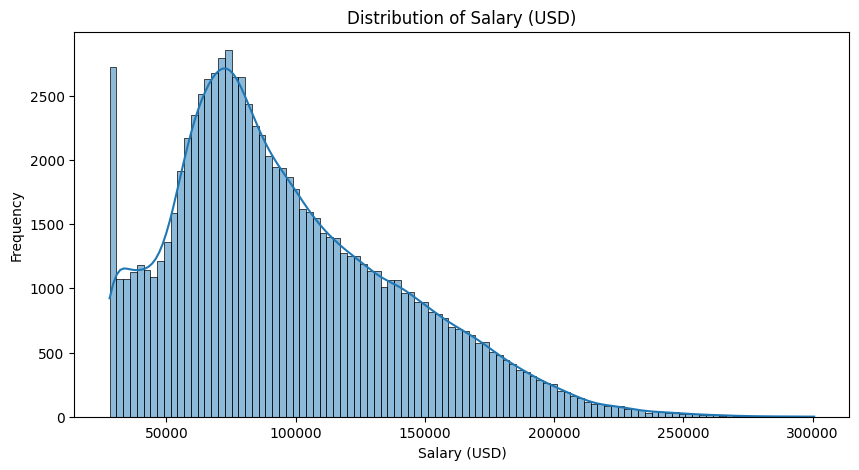

In [28]:
plt.figure(figsize=(10, 5))

sns.histplot(df["salary_usd"], kde=True)

plt.title("Distribution of Salary (USD)")
plt.xlabel("Salary (USD)")
plt.ylabel("Frequency")

plt.show()

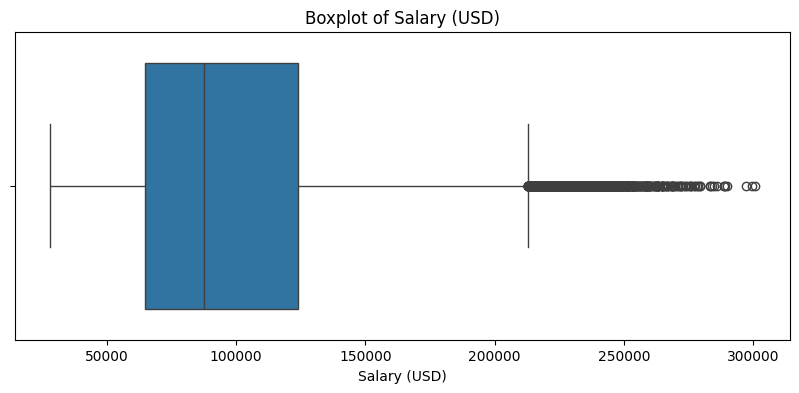

In [29]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df["salary_usd"])

plt.title("Boxplot of Salary (USD)")
plt.xlabel("Salary (USD)")

plt.show()

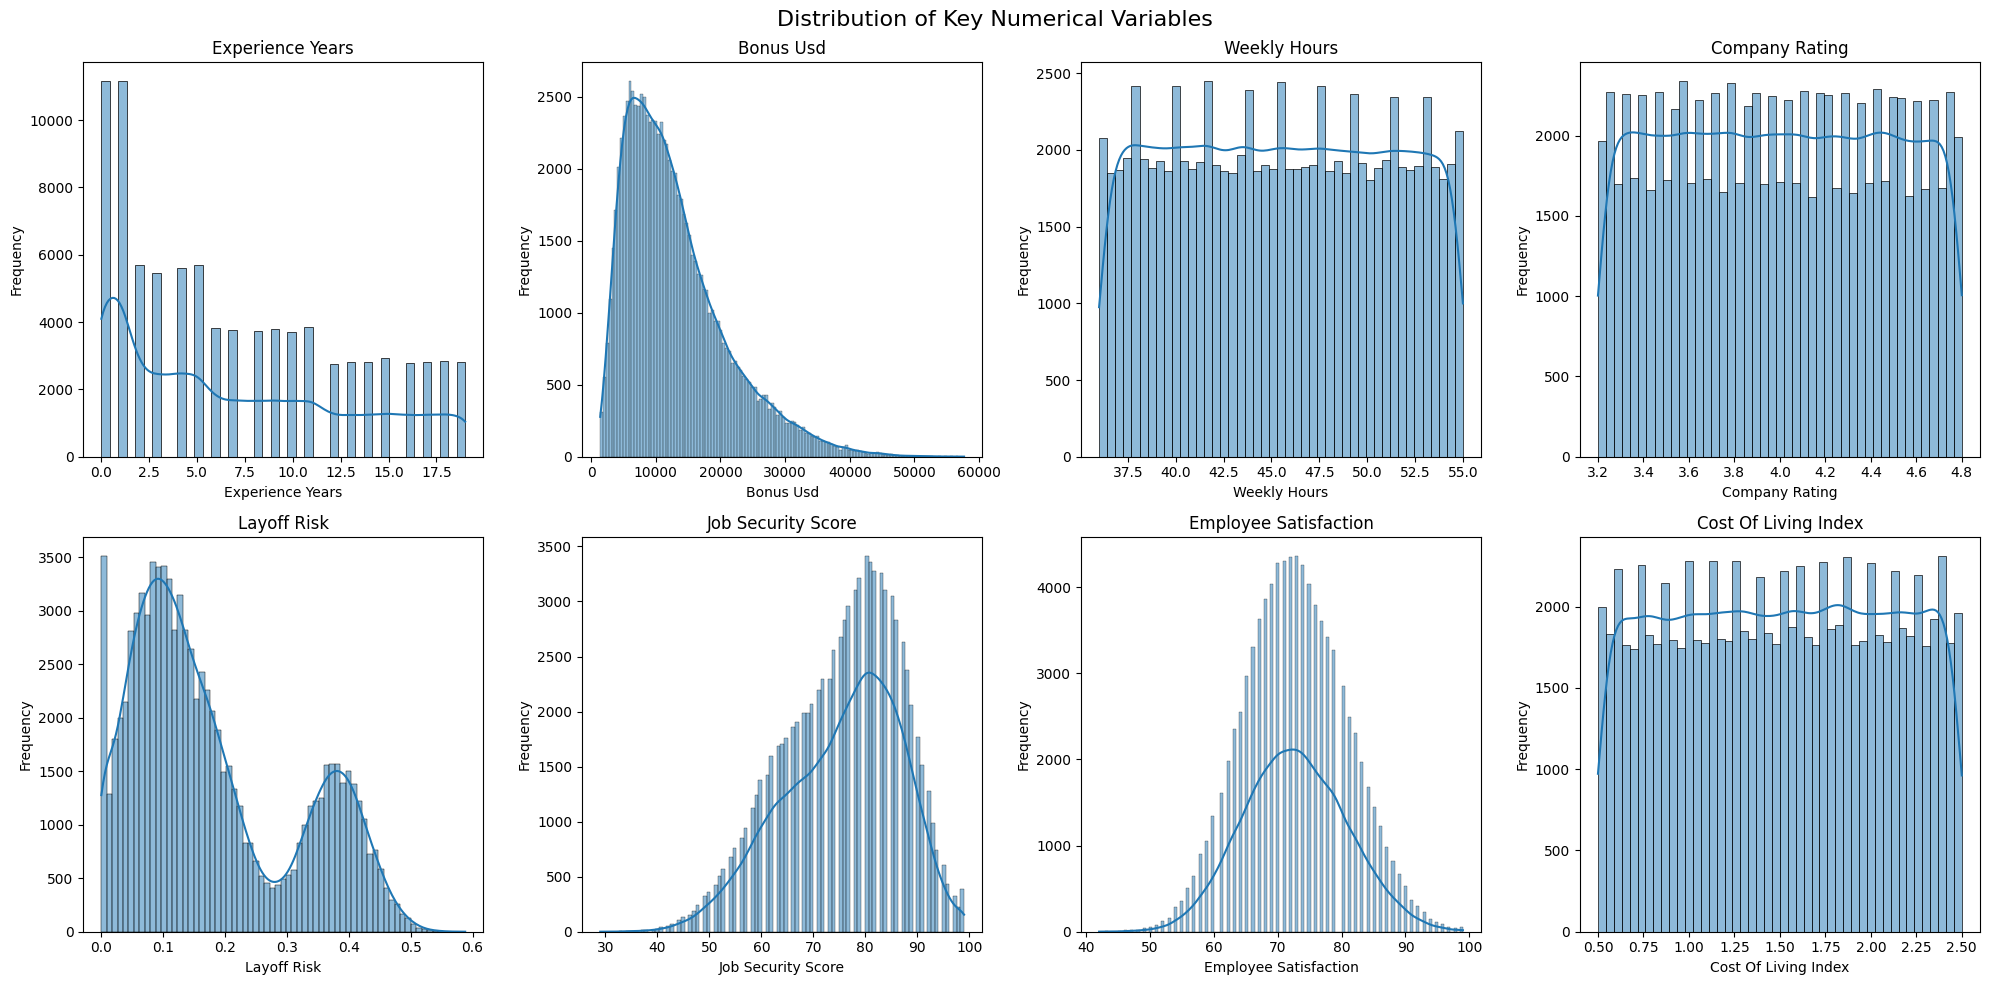

In [31]:
numerical_features = [
    "experience_years",
    "bonus_usd",
    "weekly_hours",
    "company_rating",
    "layoff_risk",
    "job_security_score",
    "employee_satisfaction",
    "cost_of_living_index"
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, column in enumerate(numerical_features):
    sns.histplot(
        df[column],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(
        column.replace("_", " ").title()
    )
    axes[i].set_xlabel(
        column.replace("_", " ").title()
    )
    axes[i].set_ylabel("Frequency")

plt.suptitle(
    "Distribution of Key Numerical Variables",
    fontsize=16
)

plt.tight_layout()
plt.show()